In [1]:
%load_ext cudf.pandas
import os
import glob
import random
import pandas as pd
from tqdm import tqdm
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import timeit

In [5]:
def benchmark_dataframe(file_path):
    """
    Loads a DataFrame from a Parquet file, randomly selects a column,
    computes unique values and benchmarks the time, then trains a RandomForestClassifier
    using that column as the only feature, and benchmarks training time.

    Returns:
        dict: A dictionary with the metrics:
              - file: the filename
              - n_rows: number of rows in the DataFrame
              - n_cols: number of columns in the DataFrame
              - selected_column: name of the randomly selected column
              - cardinality: number of unique values in that column
              - dtype: dtype of the selected column
              - unique_time: time taken to compute unique values (seconds)
              - rf_train_time: time taken to train a RandomForestClassifier (seconds)
    """
    result = {}

    # Load the DataFrame
    df = pd.read_parquet(file_path)
    # import pdb; pdb.set_trace()
    n_rows, n_cols = df.shape
    result["n_rows"] = n_rows
    result["n_cols"] = n_cols

    # Randomly select one column
    col_name = random.choice(df.columns.tolist())
    col_data = df[col_name]

    # Benchmark unique computation on the selected column
    unique_time = timeit.timeit(lambda: col_data.drop_duplicates(), number=3)

    # Call the method separately to get the result.
    unique_vals = col_data.unique()

    result["unique_time"] = unique_time
    result["cardinality"] = len(unique_vals)

    # Record the column's dtype
    result["dtype"] = str(col_data.dtype)
    del df

    return result


def main():
    # Path to the directory where the Parquet files are stored
    input_dir = "/home/jupyter/generated_dataframes"
    file_pattern = os.path.join(input_dir, "*.parquet")
    files = glob.glob(file_pattern)

    results = []

    # Process each file with a progress bar
    for file in tqdm(files, desc="Benchmarking DataFrames"):
        if ".parquet" in file:
            metrics = benchmark_dataframe(file)
            results.append(metrics)
        # import pdb; pdb.set_trace()

    # Convert the results list into a DataFrame and save as CSV
    results_df = pd.DataFrame(results)
    return results_df
    # output_csv = 'benchmark_results.csv'
    # results_df.to_csv(output_csv, index=False)
    # print(f"Benchmark results saved to {output_csv}")


if __name__ == "__main__":
    df_results = main()

Benchmarking DataFrames: 100%|█████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [02:35<00:00, 64.13it/s]


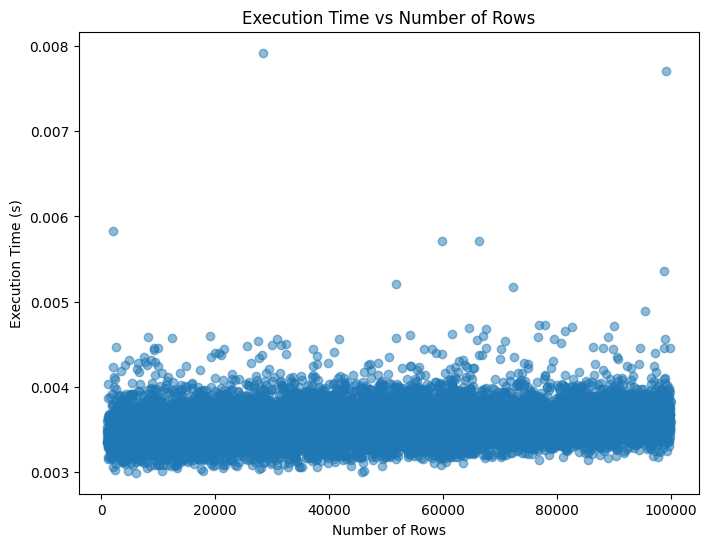

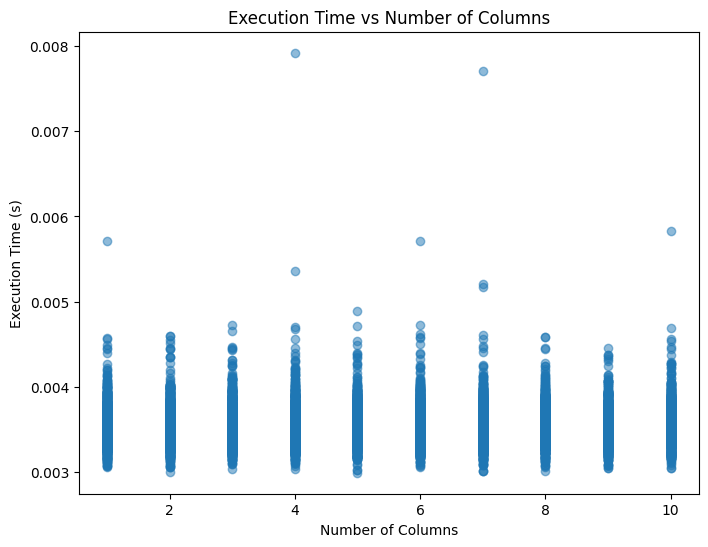

In [6]:
### plotting
import matplotlib.pyplot as plt

# Plot Execution Time vs Number of Rows
plt.figure(figsize=(8, 6))
plt.scatter(df_results["n_rows"], df_results["unique_time"], alpha=0.5)
plt.xlabel("Number of Rows")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Number of Rows")
plt.show()

# Plot Execution Time vs Number of Columns
plt.figure(figsize=(8, 6))
plt.scatter(df_results["n_cols"], df_results["unique_time"], alpha=0.5)
plt.xlabel("Number of Columns")
plt.ylabel("Execution Time (s)")
plt.title("Execution Time vs Number of Columns")
plt.show()

In [9]:
X = df_results[["n_cols", "n_rows", "dtype", "cardinality"]]
y = df_results["unique_time"]
encoder = LabelEncoder()
X["dtype"] = encoder.fit_transform(X["dtype"])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# --- Choose and Train your Model ---
print("\nTraining Model...")
for n_estimators in range(100, 150, 5):
    for max_depth in range(1, 20, 2):
        model = RandomForestRegressor(
            n_estimators=n_estimators,
            random_state=42,
            n_jobs=-1,
            max_depth=max_depth,
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # Evaluate performance
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        print("\nModel Performance (Predicting Filter Wall-Clock Time):")
        print(f"Mean Absolute Error: {mae:.6f} seconds")
        print(f"R² Score: {r2:.4f}")


Training Model...

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000145 seconds
R² Score: 0.2176

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000140 seconds
R² Score: 0.2670

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000139 seconds
R² Score: 0.2693

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000140 seconds
R² Score: 0.2589

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000142 seconds
R² Score: 0.2446

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000143 seconds
R² Score: 0.2292

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000146 seconds
R² Score: 0.2063

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000148 seconds
R² Score: 0.1817

Model Performance (Predicting Filter Wall-Clock Time):
Mean Absolute Error: 0.000151 seconds

In [ ]:
# Predict on test set
y_pred = model.predict(X_test)

# Evaluate performance
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Performance (Predicting Filter Wall-Clock Time):")
print(f"Mean Absolute Error: {mae:.6f} seconds")
print(f"R² Score: {r2:.4f}")